# <br>

<img src="logo_UNSAM.jpg" align="right" width="180" /> 

<br><br><br>

<h3 align="center">Análisis y Procesamiento de Señales</h3>

<h1 align="center"><b>TS3 - Análisis de Fourier: FFT, desparramo, interpolación y ventaneo </b></h1>
<h3 align="center">Paloma Ribnikar Diaz</h3>


## Objetivos
$\quad$ El objetivo principal que presenta este trabajo semanal es el de analizar el efecto de **Desparramo Espectral (Spectral Leakage)**. Para poder llevarlo a cabo, se parte de una senoidal de potencia normalizada (energía/varianza unitaria) cuya frecuencia $f_0$ se define en función del tamaño de casillero (bin) de la grilla de la FFT, es decir:

$$f_0 = k_0 \cdot \frac{f_S}{N} = k_0 \cdot \Delta f$$

$\quad$ Para ello, lo que se busca es parametrizar $k_0$ para sintonizar o desintonizar la senoidal respecto de las marcas fijas de la grilla frecuencial. Las variaciones analizadas a lo largo de este informe fueron:

* $k_0 = \frac{N}{4}$
* $k_0 = \frac{N}{4} + 0.25$
* $k_0 = \frac{N}{4} + 0.5$
  
$\quad$ Por otro lado, se busca graficar las Densidades Espectrales de Potencia (PSD's) de cada senoidal, además de verificar la potencia unitaria de cada PSD mediante la **Identidad de Parseval**.

$\quad$ Por último, se emplea la técnica de *zero-padding* para aumentar de forma ficticia la resolución espectral ($\Delta f$) y poder así realizar un análisis que complemente y nos permita visualizar mejor y de forma más detallada el fenómeno de interpolación espectral y la sinc, transformada de la ventana rectangular, que estuvo de forma implícita en el desarrollo de las TS's anteriores.

## Introducción

### Ventaneo Rectangular Implícito
$\quad$ El simple hecho de limitar la observación de una señal senoidal continua e infinita a un bloque finito de $N$ muestras equivale a multiplicarla en el dominio temporal por una **ventana rectangular** $w_R[n]$. En el dominio frecuencial, esta multiplicación se traduce en la convolución del espectro ideal de la senoidal con la transformada de la ventana, resultando en una función $\text{sinc}$ periódica (kernel de Dirichlet $W_R(f)$) centrada en la frecuencia fundamental $f_0$. Dicha función presenta un lóbulo principal en $f_0$ y cruces por cero periódicos ubicados a los costados.

### Resolución Espectral y Desparramo Espectral (Spectral Leakage)
$\quad$ Hasta ahora, el enfoque principal había estado centrado en la discretización del eje temporal mediante el muestreo (DTFT). Sin embargo, al no ser posible almacenar infinitos puntos continuos en la memoria RAM, la aplicación de la Transformada Discreta de Fourier (DFT) —calculada mediante el algoritmo FFT— nos permite discretizar el eje de frecuencias tomando $N$ puntos equiespaciados entre $0$ y la frecuencia de muestreo $f_S$. Al dividir los $f_S\text{ Hz}$ en $N$ porciones, imponemos una grilla discreta con casilleros (*bins*) separados por la **resolución espectral**:

$$\Delta f = \frac{f_S}{N}$$

$\quad$ Hasta el momento se venían analizando casos donde la "foto" que toma la FFT cae justo en la punta del pico central y en los cruces por cero de todos los demás bins (muestreo coherente, $k_0 \in \mathbb{Z}$). Sin embargo, en este informe se evalúan los casos donde $k_0$ no es entero (existe una desintonía). Al desplazarse la ventana $\text{sinc}$, las marcas fijas de la grilla no coinciden con los cruces por cero, sino que "muestran" la ladera del lóbulo principal y los lóbulos laterales de la $\text{sinc}$. La energía se desparrama hacia frecuencias vecinas, fenómeno conocido como **desparramo espectral (spectral leakage)**.

### Teorema de Parseval y Scalloping Loss
$\quad$ La **Identidad de Parseval** establece el principio de conservación de la potencia entre el dominio del tiempo y el dominio de la frecuencia:

$$P_{\text{tiempo}} = \frac{1}{N} \sum_{n=0}^{N-1} |x[n]|^2 = \sum_{k=0}^{N-1} \left| \frac{X[k]}{N} \right|^2 = P_{\text{frecuencia}}$$

$\quad$ Para una senoidal de potencia unitaria ($P = 1\text{ W}$), la suma de las alturas al cuadrado de todos los bins de la FFT debe mantenerse constante e igual a $1\text{ W}$. Cuando la señal está sintonizada ($k_0 \in \mathbb{Z}$), dicha potencia se concentra en un único bin. En cambio, cuando ocurre desintonía, la potencia se distribuye entre docenas de bins vecinos. La caída de la amplitud del bin central se conoce como **pérdida por festoneado (*scalloping loss*)**, en donde la energía no se destruye, sino que se redistribuye a los costados.

### Zero-Padding e Interpolación Espectral
$\quad$ El agregado de ceros al final de la señal (por ejemplo, $9N$ ceros para completar $M = 10N$ puntos) presenta dos efectos principales en la secuencia extendida:

* **Efecto en la grilla:** La nueva resolución espectral pasa a ser $\Delta f_{\text{nuevo}} = \frac{f_S}{10N} = \frac{\Delta f}{10}$, es decir, la grilla de frecuencias se vuelve 10 veces más tupida. Los casilleros se encuentran 10 veces más apretados entre sí: es como si le sacáramos 10 veces más "fotos" a la $\text{sinc}$ que flota de fondo, permitiendo dibujar su curva de forma suave.

* **Efecto en el gráfico (Interpolación Espectral):** No se agrega información física nueva a la señal, pero al tener 10 veces más puntos de muestreo en frecuencia, se puede visualizar la curva continua de la ventana $\text{sinc}$ que antes quedaba oculta entre bins lejanos. En consecuencia, la técnica de *zero-padding* actúa como un **interpolador espectral**, demostrando visualmente que la $\text{sinc}$ de fondo siempre estuvo allí.

## Desarrollo y Análisis

## Código en Python

### Librerías y Definiciones

In [2]:
# -*- coding: utf-8 -*-
"""
Created on Sun Aug 30 17:36:34 2026

@author: ribni
"""

#%% LIBRERIAS

import numpy as np
import matplotlib.pyplot as plt

#%% DEFINICIONES

# Parámetros del ADC
N = 1000 # Cantidad de muestras
fs = 1000 # Frecuencia de muestreo, 20KHz

# RESOLUCIÓN ESPECTRAL
df = fs / N

# Parámetros de la función sinusoidal
ff = 2000 # Frecuencia de la señal analógica

vmax = np.sqrt (2)  # Amplitud pico (volts) -> sqrt(2) para lograr 1 Watt de potencia
dc = 0  # Valor medio / offset (volts)
ph = 0  # Fase inicial (rad)

### Funciones

$\quad$ En este apartado se define la función senoidal base $s(t) = V_{\max} \sin(2\pi f_0 t + \phi) + DC$ con potencia unitaria $P_s = 1\text{ W}$ y amplitud pico $V_{\max} = \sqrt{2}\text{ V}$ (que viene siendo foco de análisis en las entregas semanales). Para el análisis espectral, se implementa una función que calcula el módulo de la FFT normalizado por $N$ y toma los $N/2$ bins de frecuencias positivas ($0$ a $f_S/2$). La potencia lineal promedio por bin se convierte a escala logarítmica mediante $10 \log_{10}(P + 10^{-12})$.

In [3]:
#%% FUNCIONES
''' Función Senoidal '''
def mi_funcion_sen(vmax = np.sqrt (2), dc = 0, ff = 1, ph=0, nn = N, fs = fs):
    
    # Rango de 0 a N-1 --> tiempo discreto
    tt =  (np.arange (nn) / fs) #np.arange para generar un vector de N nros
    
    # Señal Senoidal
    xx = vmax * np.sin (2 * np.pi * (ff * tt) + ph) + dc
    
    return tt, xx

""" PSD: Densidad Espectral de Potencia calibrada en dB """
def calcular_psd_db (x, N):
    
    # Primero calculo la FFT de la señal
    X = np.fft.fft(x, n = N) # El segundo parámetro n significa --> Quiero que la FFT tenga n puntos
    
    # Nyquist: Módulo y me quedo solo con la mitad positiva (banda útil de frecuencia)
    X_abs = np.abs(X[:N//2])
    
    # Normalizo dividiendo por N y multiplicando por 2
    X_norm = (2 * X_abs) / 1000
    
    # Formula de potencia --> elevo al cuadrado y divido por 2 para tener Watts
    potencia_lineal = (X_norm)**2 / 2
    
    # paso a decibeles con escala log y aplicando "parche"
    psd_dB = 10 * np.log10(potencia_lineal + 1e-12)
    
    return psd_dB

### Script

$\quad$ En una primera instancia, se definen los ejes de frecuencia que se emplearán luego para los gráficos de los dominios espectrales:

In [4]:
#%% SCRIPT

# Eje de frecuencia genérico para todas las FFT
ff_vector = np.fft.fftfreq(N, d=1 / fs)
ff_vector_pos = ff_vector[:N//2] # Solo tomo los valores positivos (simetrico)

# Eje de frecuencia para la ver. padded
ff_vector_padded = np.fft.fftfreq(10 * N, d=1 / fs)
ff_vector_pos_padded = ff_vector_padded[:10 * N // 2]


<h4><font color='#ba5653'> <b> INCISO A  — Análisis del Efecto de Desintonía Frecuencial </b> </font></h4>

$\quad$ A continuación, se ejecutan las funciones del apartado anterior con el fin de generar tres señales senoidales de potencia unitaria ($P_s = 1\text{ W}$) que difieren en el parámetro $k_0$ para introducir desintonía respecto a la grilla frecuencial ($\Delta f$). Para poder evaluar visualmente la manifestación del fenómeno de **desparramo espectral (spectral leakage)** y su implicancia energética, se graficaron sus **Densidades Espectrales de Potencia (PSD)** superpuestas.

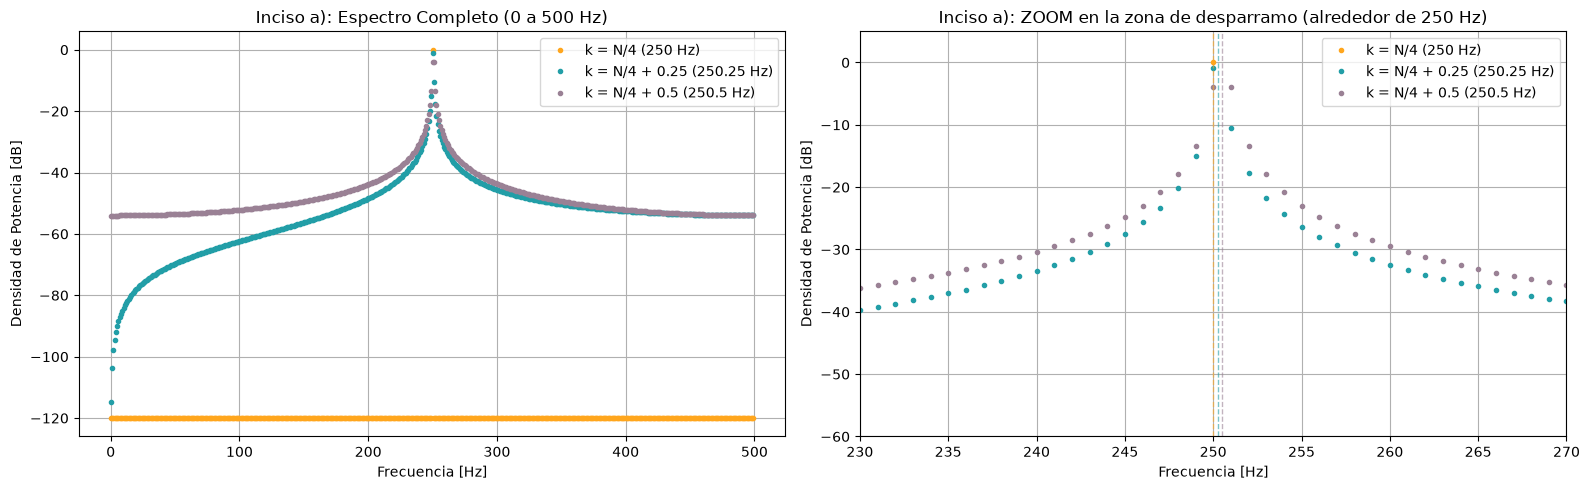

In [5]:
#%% INCISO A - DENSIDAD ESPECTRAL DE POTENCIA (SUBPLOTS CON Y SIN ZOOM)

# Abrimos la figura con 2 subgráficos (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# CASO 1: k = N/4 (250 Hz)
ff_actual1 = (N/4) * df
tt, xx1 = mi_funcion_sen(vmax=vmax, dc=0, ff=ff_actual1, ph=0, nn=N, fs=fs)
salida1_dB = calcular_psd_db(xx1, N)

# CASO 2: k = N/4 + 0.25 (250.25 Hz)
ff_actual2 = (N/4 + 0.25) * df
tt, xx2 = mi_funcion_sen(vmax = vmax, dc = 0, ff = ff_actual2, ph = 0, nn = N, fs = fs)   
salida2_dB = calcular_psd_db(xx2, N)

# CASO 3: k = N/4 + 0.5 (250.5 Hz)
ff_actual3 = (N/4 + 0.5) * df
tt, xx3 = mi_funcion_sen(vmax = vmax, dc = 0, ff = ff_actual3, ph = 0, nn = N, fs = fs)   
salida3_dB = calcular_psd_db(xx3, N)

# --- DERECHA E IZQUIERDA: Graficamos las curvas en ambos ejes ---
for ax in (ax1, ax2):
    ax.plot(ff_vector_pos, salida1_dB, 'o', markersize=3, label='k = N/4 (250 Hz)', color='#ffa61d')
    ax.plot(ff_vector_pos, salida2_dB, 'o', markersize=3, label='k = N/4 + 0.25 (250.25 Hz)', color='#229ea7')
    ax.plot(ff_vector_pos, salida3_dB, 'o', markersize=3, label='k = N/4 + 0.5 (250.5 Hz)', color='#9a8195')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel('Densidad de Potencia [dB]')
    ax.legend(loc='upper right')
    ax.grid(True)

# Configuración del Subplot 1 (Panorámico sin zoom)
ax1.set_title('Inciso a): Espectro Completo (0 a 500 Hz)')

# Configuración del Subplot 2 (Con ZOOM activado)
ax2.set_title('Inciso a): ZOOM en la zona de desparramo (alrededor de 250 Hz)')
ax2.set_xlim(230, 270) # Zoom en la zona de desparramo (alrededor de 250 Hz)
ax2.set_ylim(-60, 5)

# LÍNEAS VERTICALES DE REF. (en el subgráfico con Zoom)
ax2.axvline(x=250.0, color='#ffa61d', linestyle='--', linewidth=1, alpha=0.6)
ax2.axvline(x=250.25, color='#229ea7', linestyle='--', linewidth=1, alpha=0.6)
ax2.axvline(x=250.5, color='#9a8195', linestyle='--', linewidth=1, alpha=0.6)

plt.tight_layout()
plt.show()

<h4><font color='#950753'><b>Análisis</b></font></h4>

$\quad$ Tal como se observa en los gráficos de la Densidad Espectral de Potencia (PSD), se evaluó el efecto de la desintonía frecuencial respecto a las marcas fijas de la grilla de la FFT ($\Delta f = 1\text{ Hz}$). El gráfico de la derecha presenta una ampliación (zoom en la zona de $230\text{ Hz}$ a $270\text{ Hz}$) para apreciar en detalle cómo se ubican las muestras de la FFT sobre el espectro de cada senoidal:

* **Caso $k_0 = N/4 = 250\text{ Hz}$ (Muestreo Coherente):** 
  La frecuencia de la senoidal coincide exactamente con el casillero $k = 250$ de la grilla. Dado que el ventaneo rectangular genera una función $\text{sinc}$ centrada en $f_0$, los demás casilleros enteros de la FFT coinciden exactamente con los **cruces por cero** de dicha $\text{sinc}$. Por este motivo, toda la potencia ($1\text{ W} = 0\text{ dB}$) se observa concentrada en un único bin en $250\text{ Hz}$, mientras que en los demás bins el nivel cae al piso numérico ($-120\text{ dB}$). No existe desparramo visible.

* **Caso $k_0 = N/4 + 0.25 = 250.25\text{ Hz}$ (Desintonía Intermedia):** 
  Al desplazarse la frecuencia $0.25\text{ Hz}$, la ventana $\text{sinc}$ continua se corre de lugar. Dado que la grilla de la FFT permanece fija en frecuencias enteras ($249, 250, 251\text{ Hz}\dots$), las muestras tomadas por la FFT ya no coinciden con los cruces por cero, sino que "fotografían" la ladera y los lóbulos laterales de la $\text{sinc}$. Esto provoca que la energía se desparrame hacia casilleros vecinos (**desparramo espectral / spectral leakage**) y que el bin $250$ pierda el nivel pico de $0\text{ dB}$ bajando a $-4.1\text{ dB}$ (**pérdida por festoneado / scalloping loss**).

* **Caso $k_0 = N/4 + 0.5 = 250.5\text{ Hz}$ (Máxima Desintonía):** 
  Al situarse la frecuencia exactamente en el punto medio entre dos casilleros ($250.5\text{ Hz}$), se alcanza el caso de **desintonía máxima**. Ningún bin de la FFT logra capturar la cima del lóbulo principal; los bins $250$ y $251$ toman simétricamente un valor atenuado de $-3.92\text{ dB}$. Asimismo, la FFT muestrea los lóbulos secundarios en sus crestas más altas, produciendo la mayor fuga de energía hacia todo el espectro (elevando las alas del espectro hasta unos $-54\text{ dB}$).

<h4><font color='#a2302c'> <b> INCISO B - Verificación de Potencia (Parseval)  </b> </font></h4>

$\quad$ Para el desarrollo de este inciso, se aplicó la **identidad de Parseval** con el objetivo de calcular y comparar cuantitativamente la potencia promedio de las tres señales senoidales tanto en el dominio del tiempo como en el dominio de la frecuencia, verificando la conservación de la potencia unitaria ($P = 1\text{ W}$).

In [6]:
#%% INCISO B - Potencia unitaria de cada PSD con identidad de Parseval

# Potencia de la señal en el dominio temporal
P_tiempo1 = np.mean(xx1**2)
P_tiempo2 = np.mean(xx2**2)
P_tiempo3 = np.mean(xx3**2)

# Potencia de la señal en el dominio frecuencial
P_frecuencia1 = np.sum(2 * (np.abs(np.fft.fft(xx1)[:N//2]) / N)**2)
P_frecuencia2 = np.sum(2 * (np.abs(np.fft.fft(xx2)[:N//2]) / N)**2)
P_frecuencia3 = np.sum(2 * (np.abs(np.fft.fft(xx3)[:N//2]) / N)**2)

print('Caso 1:')
print('Potencia temporal:', P_tiempo1, 'W')
print('Potencia frecuencial:', P_frecuencia1, 'W')

print('\nCaso 2:')
print('Potencia temporal:', P_tiempo2, 'W')
print('Potencia frecuencial:', P_frecuencia2, 'W')

print('\nCaso 3:')
print('Potencia temporal:', P_tiempo3, 'W')
print('Potencia frecuencial:', P_frecuencia3, 'W')

Caso 1:
Potencia temporal: 1.0000000000000002 W
Potencia frecuencial: 1.0000000000000002 W

Caso 2:
Potencia temporal: 0.9989999999999998 W
Potencia frecuencial: 0.9989979968559336 W

Caso 3:
Potencia temporal: 1.0000000000000004 W
Potencia frecuencial: 0.9999999748670526 W


<h4><font color='#950753'><b>Análisis valores impresos:</b></font></h4>

$\quad$ Los valores impresos confirman cuantitativamente el cumplimiento del **Teorema de Parseval** para los tres casos analizados.
*¿Por qué una señal senoidal tiene un espectro tan diferente respecto a otra de muy pocos Hertz de diferencia?*
$\quad$ La razón principal radica en la distribución de la potencia que se produce entre los casilleros de la FFT:
* **Invariancia de la Potencia Total:** La potencia depende únicamente de la amplitud pico que establecimos inicialmente para que la señal analizada sea unitaria ($P = 1\text{ W}$). El desparramo espectral no destruye energía, sino que la redistribuye a lo largo del eje frecuencial.
* **Concentración vs. Redistribución:** En $250\text{ Hz}$ (señal sintonizada), el $100\%$ de la potencia está concentrada en un único casillero (bin $250$). En $250.25\text{ Hz}$ y $250.5\text{ Hz}$ (desintonizadas), la potencia del bin central cae (fenómeno que definimos como *scalloping loss* o pérdida por festoneado), pero la potencia faltante se desparrama hacia las colas de los casilleros vecinos. Al sumar las potencias de todos los bins de la FFT, la sumatoria vuelve a dar exactamente el $100\%$ de la potencia unitaria ($1\text{ Watt}$).


<h4><font color='#a2302c'> <b> INCISO C - Interpolación Espectral mediante Zero-Padding </b> </font></h4>

$\quad$ Se repitieron las experiencias de los incisos A y B aplicando la técnica de *Zero-Padding* (agregado de $9N$ ceros al final de la secuencia temporal). Para lograrlo, se definió el parámetro N_padded = 10 * N ($10.000$ puntos en total, correspondiente a las $N$ muestras de la señal más los $9N$ ceros).

$\quad$ Dentro de la función que calcula la Transformada de Fourier, se pasa la instrucción X = np.fft.fft(x, n=N_padded). El parámetro n le indica a la librería NumPy que la FFT tenga $10N$ puntos; al ser mayor que la longitud de la señal original ($N=1000$), NumPy completa automáticamente el vector agregando los $9N$ ceros al final y evalúa el espectro en una grilla $10$ veces más tupida.

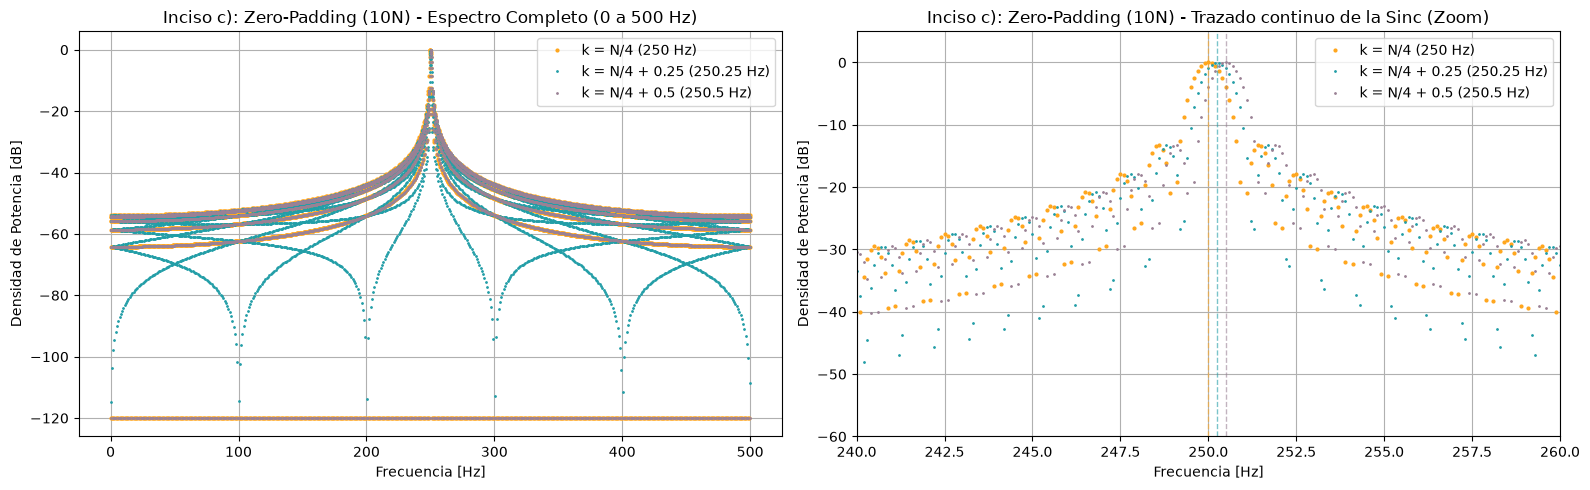

In [7]:
#%% INCISO C - Zero-padding

# INCISO A - REPETIDO
# Agregando un vector de 9N ceros al final
N_padded = 10 * N  # 10.000 puntos en total (N muestras + 9N ceros)

# Abrimos la figura con 2 subgráficos (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# CASO 1: k = N/4 (250 Hz)
ff_actual1 = (N/4) * df
tt, xx1 = mi_funcion_sen(vmax=vmax, dc=0, ff=ff_actual1, ph=0, nn = N, fs=fs)
salida1_dB = calcular_psd_db(xx1, N_padded)

# CASO 2: k = N/4 + 0.25 (250.25 Hz)
ff_actual2 = (N/4 + 0.25) * df
tt, xx2 = mi_funcion_sen(vmax = vmax, dc = 0, ff = ff_actual2, ph = 0, nn = N, fs = fs)   
salida2_dB = calcular_psd_db(xx2, N_padded)

# CASO 3: k = N/4 + 0.5 (250.5 Hz)
ff_actual3 = (N/4 + 0.5) * df
tt, xx3 = mi_funcion_sen(vmax = vmax, dc = 0, ff = ff_actual3, ph = 0, nn = N, fs = fs)   
salida3_dB = calcular_psd_db(xx3, N_padded)

# Grafico curvas en ambos ejes
for ax in (ax1, ax2):
    ax.plot(ff_vector_pos_padded, salida1_dB, 'o', markersize=2, label='k = N/4 (250 Hz)', color='#ffa61d')
    ax.plot(ff_vector_pos_padded, salida2_dB, 'o', markersize=1, label='k = N/4 + 0.25 (250.25 Hz)', color='#229ea7')
    ax.plot(ff_vector_pos_padded, salida3_dB, 'o', markersize=1, label='k = N/4 + 0.5 (250.5 Hz)', color='#9a8195')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel('Densidad de Potencia [dB]')
    ax.legend(loc='upper right')
    ax.grid(True)

# Configuración del Subplot 1 (sin zoom)
ax1.set_title('Inciso c): Zero-Padding (10N) - Espectro Completo (0 a 500 Hz)')

# Configuración del Subplot 2 (Con ZOOM)
ax2.set_title('Inciso c): Zero-Padding (10N) - Trazado continuo de la Sinc (Zoom)')
ax2.set_xlim(240, 260)  # ZOOM fundamental alrededor de 250 Hz
ax2.set_ylim(-60, 5)

ax2.axvline(x=250.0, color='#ffa61d', linestyle='--', linewidth=1, alpha=0.6)
ax2.axvline(x=250.25, color='#229ea7', linestyle='--', linewidth=1, alpha=0.6)
ax2.axvline(x=250.5, color='#9a8195', linestyle='--', linewidth=1, alpha=0.6)

plt.tight_layout()
plt.show()

<h4><font color='#950753'><b>Análisis</b></font></h4>

$\quad$ El análisis resulta análogo al realizado en el Inciso A. Lo imprescindible a destacar es que, con el agregado de la técnica de *zero-padding* ($10N$), resulta más evidente que la restricción de $N$ muestras sobre una señal senoidal implica un ventaneo en el tiempo cuya transformada en frecuencia es la función $\text{sinc}$.

$\quad$ Al observar los gráficos obtenidos, podemos destacar dos aspectos fundamentales:

* **Interpolación Espectral:** No se agrega información física nueva a la señal ni cambia su resolución real, pero al volver la grilla de frecuencias 10 veces más tupida ($\Delta f_{\text{nuevo}} = 0.1\text{ Hz}$), el *zero-padding* actúa como un **interpolador espectral**. Esto nos permite visualizar con gran definición la curva continua y suave de la ventana $\text{sinc}$ (lóbulo principal y lóbulos secundarios) que en el Inciso A quedaba oculta o submuestreada entre casilleros lejanos.

* **Visualización del Desplazamiento:** En el gráfico con Zoom se aprecia claramente la estructura completa de la $\text{sinc}$ desplazándose horizontalmente. Mientras que en $k_0 = 250\text{ Hz}$ la grilla original de $1\text{ Hz}$ le pegaba justo a la cima ($0\text{ dB}$) y a los cruces por cero, en $k_0 = 250.25\text{ Hz}$ y $250.5\text{ Hz}$ la curva desplazada demuestra por qué los bins fijos capturaban valores atenuados en el centro y valores altos en los lóbulos laterales, originando el desparramo espectral.

In [8]:
# INCISO B - REPETIDO
# Potencia de la señal en el dominio temporal
P_tiempo1_padding = np.mean(xx1**2)
P_tiempo2_padding = np.mean(xx2**2)
P_tiempo3_padding = np.mean(xx3**2)

# Potencia de la señal en el dominio frecuencial
P_frecuencia1_padding = np.sum(2 * (np.abs(np.fft.fft(xx1, N_padded)[:N_padded//2]) / N_padded)**2)
P_frecuencia2_padding = np.sum(2 * (np.abs(np.fft.fft(xx2, N_padded)[:N_padded//2]) / N_padded)**2)
P_frecuencia3_padding = np.sum(2 * (np.abs(np.fft.fft(xx3, N_padded)[:N_padded//2]) / N_padded)**2)

print('Caso 1:')
print('Potencia temporal:', P_tiempo1_padding, 'W')
print('Potencia frecuencial:', P_frecuencia1_padding, 'W')

print('\nCaso 2:')
print('Potencia temporal:', P_tiempo2_padding, 'W')
print('Potencia frecuencial:', P_frecuencia2_padding, 'W')

print('\nCaso 3:')
print('Potencia temporal:', P_tiempo3_padding, 'W')
print('Potencia frecuencial:', P_frecuencia3_padding, 'W')

Caso 1:
Potencia temporal: 1.0000000000000002 W
Potencia frecuencial: 0.10000000000000003 W

Caso 2:
Potencia temporal: 0.9989999999999998 W
Potencia frecuencial: 0.09989997996855933 W

Caso 3:
Potencia temporal: 1.0000000000000004 W
Potencia frecuencial: 0.09999999974867059 W


<h4><font color='#950753'><b>Análisis valores impresos:</b></font></h4>

$\quad$ Resulta posible confirmar que la conservación de la potencia establecida por el **Teorema de Parseval** se mantiene intacta tras aplicar *zero-padding*, es decir, el agregado de ceros no altera la energía física original de la señal ($1\text{ W}$), únicamente redistribuye los puntos de evaluación en la frecuencia para brindar una visualización de alta definición de la respuesta espectral.

## Conclusión



$\quad$ Con el desarrollo de esta tarea semanal, fue posible comprender que la razón teórica por la cual dos senoidales con apenas centésimas de Hertz de diferencia presentan espectros visuales tan distintos **radica en la interacción entre el desplazamiento de la función $\text{sinc}$ (producto del ventaneo implícito) y los puntos de muestreo fijos de la grilla de la FFT**.

$\quad$ Asimismo, mediante la aplicación de la **Identidad de Parseval** se demostró cuantitativamente que el fenómeno de desparramo espectral (*spectral leakage*) no implica una pérdida de energía física, sino una redistribución de la potencia a lo largo del dominio frecuencial (*scalloping loss*). Finalmente, se comprobó que la técnica de ***zero-padding*** funciona como un interpolador espectral que permite visualizar la estructura continua de la $\text{sinc}$ de fondo, sin alterar la potencia total ni agregar información física nueva a la señal.

## Bibliografía
> Holton, T. (2021). Digital Signal Processing: Principles and Applications. Cambridge University Press.<br>
> Lyons, R. G. (2011). Understanding Digital Signal Processing (3rd ed.). Prentice Hall.<br>
> Downey, A. B. (2016). Think DSP: Digital Signal Processing in Python. O'Reilly Media.<br>
> Porat, B. (1997). A Course in Digital Signal Processing. John Wiley & Sons.<br>
> Hayes, M. H. (1996). Statistical Digital Signal Processing and Modeling. John Wiley & Sons.